# Notebook 05: Évaluation et Analyse Finale

Ce notebook réalise l'évaluation finale du pipeline, compare l'approche semi-supervisée à une approche supervisée classique et résume l'intérêt métier.

In [10]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

DATA_DIR = Path('../data')
LABELED_DIR = DATA_DIR / 'avec_labels'
UNLABELED_DIR = DATA_DIR / 'sans_label'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cpu


## 1. Chargement des résultats

In [11]:
records = []

for label_name, folder in {
    'cancer': LABELED_DIR / 'cancer',
    'normal': LABELED_DIR / 'normal'
}.items():
    if folder.exists():
        for img_path in sorted(folder.glob('*.jpg')):
            records.append({
                'image_id': img_path.stem,
                'image_path': str(img_path.resolve()),
                'label': label_name,
                'source': 'avec_labels'
            })

if UNLABELED_DIR.exists():
    for img_path in sorted(UNLABELED_DIR.glob('*.jpg')):
        records.append({
            'image_id': img_path.stem,
            'image_path': str(img_path.resolve()),
            'label': 'sans_label',
            'source': 'sans_label'
        })

metadata = pd.DataFrame(records)

features_path = PROCESSED_DIR / 'features_resnet50.npy'
if not features_path.exists():
    raise FileNotFoundError(f"Fichier introuvable : {features_path}")

X = np.load(features_path).astype(np.float32)

analysis_csv_path = RESULTS_DIR / 'mri_metadata_clusters_notebook3.csv'
if not analysis_csv_path.exists():
    raise FileNotFoundError(f"Fichier introuvable : {analysis_csv_path}")

analysis_df = pd.read_csv(analysis_csv_path)

if len(X) != len(analysis_df):
    raise ValueError(f"Mismatch : {len(X)} features vs {len(analysis_df)} lignes analysis_df")

if 'weak_label' not in analysis_df.columns:
    raise ValueError("La colonne 'weak_label' est absente du CSV du notebook 3.")

label_to_int = {'normal': 0, 'cancer': 1}

weak_labels = analysis_df['weak_label'].map(label_to_int).to_numpy()

labeled_mask = analysis_df['label'].isin(['normal', 'cancer']).to_numpy()
labeled_indices = np.where(labeled_mask)[0]
true_labels_labeled = analysis_df.loc[labeled_mask, 'label'].map(label_to_int).to_numpy()

print("X shape:", X.shape)
print("weak_labels shape:", weak_labels.shape)
print("Nombre d'images labellisées :", len(labeled_indices))
print("Répartition labels réels :")
print(analysis_df.loc[labeled_mask, 'label'].value_counts())

X shape: (1506, 2048)
weak_labels shape: (1506,)
Nombre d'images labellisées : 100
Répartition labels réels :
label
cancer    50
normal    50
Name: count, dtype: int64


## 2. Génération de données de test simulées

In [12]:
labeled_train_idx, labeled_temp_idx = train_test_split(
    labeled_indices,
    test_size=0.30,
    random_state=42,
    stratify=true_labels_labeled
)

temp_true = analysis_df.loc[labeled_temp_idx, 'label'].map(label_to_int).to_numpy()

labeled_val_idx, labeled_test_idx = train_test_split(
    labeled_temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_true
)

unlabeled_indices = np.where(~labeled_mask)[0]

# Semi-supervisé : unlabeled + labeled_train
semi_train_idx = np.concatenate([unlabeled_indices, labeled_train_idx])

semi_train_labels = weak_labels.copy()
semi_train_labels[labeled_train_idx] = analysis_df.loc[labeled_train_idx, 'label'].map(label_to_int).to_numpy()

# Supervisé pur : seulement les labeled_train
sup_train_idx = labeled_train_idx
sup_train_labels = analysis_df.loc[sup_train_idx, 'label'].map(label_to_int).to_numpy()

# Validation / test toujours sur vraies données labellisées
val_labels = analysis_df.loc[labeled_val_idx, 'label'].map(label_to_int).to_numpy()
test_labels = analysis_df.loc[labeled_test_idx, 'label'].map(label_to_int).to_numpy()

print("Train semi-supervisé :", len(semi_train_idx))
print("Train supervisé pur  :", len(sup_train_idx))
print("Validation           :", len(labeled_val_idx))
print("Test                 :", len(labeled_test_idx))

Train semi-supervisé : 1476
Train supervisé pur  : 70
Validation           : 15
Test                 : 15


## 3. Matrices de confusion

In [13]:
def make_loader(indices, labels, batch_size=32, shuffle=True):
    x_tensor = torch.tensor(X[indices], dtype=torch.float32)
    y_tensor = torch.tensor(labels, dtype=torch.long)
    ds = TensorDataset(x_tensor, y_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

semi_train_loader = make_loader(semi_train_idx, semi_train_labels[semi_train_idx], batch_size=32, shuffle=True)
sup_train_loader = make_loader(sup_train_idx, sup_train_labels, batch_size=16, shuffle=True)

val_loader = make_loader(labeled_val_idx, val_labels, batch_size=32, shuffle=False)
test_loader = make_loader(labeled_test_idx, test_labels, batch_size=32, shuffle=False)

print("✅ DataLoaders prêts")

✅ DataLoaders prêts


## 4. Métriques détaillées

In [14]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim=2048, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.net(x)

n_features = X.shape[1]

def build_model():
    return SimpleClassifier(input_dim=n_features).to(DEVICE)

def make_weighted_loss(labels_array):
    class_counts = np.bincount(labels_array, minlength=2)
    class_weights = class_counts.sum() / (2 * class_counts)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    return nn.CrossEntropyLoss(weight=weights_tensor), class_weights

semi_criterion, semi_class_weights = make_weighted_loss(semi_train_labels[semi_train_idx])
sup_criterion, sup_class_weights = make_weighted_loss(sup_train_labels)

print("Class weights semi :", semi_class_weights)
print("Class weights sup  :", sup_class_weights)

Class weights semi : [1.16772152 0.87440758]
Class weights sup  : [1. 1.]


## 5. Courbes ROC

In [16]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            logits = model(xb)
            loss = criterion(logits, yb)

            if train:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * len(xb)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(y_true)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc, np.array(y_true), np.array(y_pred)

def train_model(model, train_loader, val_loader, criterion, n_epochs=8, lr=1e-3, model_name='model'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_val_acc = -1.0
    best_path = MODELS_DIR / f'best_{model_name}.pth'

    for epoch in range(n_epochs):
        train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer)
        val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_path)

        print(
            f"{model_name} | Epoch {epoch+1}/{n_epochs} - "
            f"train_acc={train_acc:.3f} - val_acc={val_acc:.3f} - "
            f"train_loss={train_loss:.4f} - val_loss={val_loss:.4f}"
        )

    return history, best_path, best_val_acc

def evaluate_model(model, test_loader, criterion):
    test_loss, test_acc, y_true, y_pred = run_epoch(model, test_loader, criterion, optimizer=None)

    results = {
        'test_loss': float(test_loss),
        'test_acc': float(test_acc),
        'precision_normal': float(precision_score(y_true, y_pred, pos_label=0, average='binary')),
        'recall_normal': float(recall_score(y_true, y_pred, pos_label=0, average='binary')),
        'f1_normal': float(f1_score(y_true, y_pred, pos_label=0, average='binary')),
        'precision_cancer': float(precision_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)),
        'recall_cancer': float(recall_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)),
        'f1_cancer': float(f1_score(y_true, y_pred, pos_label=1, average='binary', zero_division=0)),
        'y_true': y_true,
        'y_pred': y_pred
    }

    return results

## 6. Analyse économique

In [17]:
semi_model = build_model()
sup_model = build_model()

print("=== Entraînement modèle semi-supervisé ===")
semi_history, semi_best_path, semi_best_val_acc = train_model(
    semi_model,
    semi_train_loader,
    val_loader,
    semi_criterion,
    n_epochs=8,
    lr=1e-3,
    model_name='semi_supervised'
)

print("\n=== Entraînement modèle supervisé pur ===")
sup_history, sup_best_path, sup_best_val_acc = train_model(
    sup_model,
    sup_train_loader,
    val_loader,
    sup_criterion,
    n_epochs=8,
    lr=1e-3,
    model_name='supervised_only'
)

print("\nBest val acc semi :", semi_best_val_acc)
print("Best val acc sup  :", sup_best_val_acc)

=== Entraînement modèle semi-supervisé ===
semi_supervised | Epoch 1/8 - train_acc=0.938 - val_acc=0.867 - train_loss=0.2076 - val_loss=0.1544
semi_supervised | Epoch 2/8 - train_acc=0.976 - val_acc=0.933 - train_loss=0.0833 - val_loss=0.1354
semi_supervised | Epoch 3/8 - train_acc=0.980 - val_acc=0.867 - train_loss=0.0716 - val_loss=0.2956
semi_supervised | Epoch 4/8 - train_acc=0.986 - val_acc=0.867 - train_loss=0.0576 - val_loss=0.3049
semi_supervised | Epoch 5/8 - train_acc=0.988 - val_acc=0.933 - train_loss=0.0490 - val_loss=0.1186
semi_supervised | Epoch 6/8 - train_acc=0.989 - val_acc=0.867 - train_loss=0.0424 - val_loss=0.3351
semi_supervised | Epoch 7/8 - train_acc=0.992 - val_acc=0.867 - train_loss=0.0290 - val_loss=0.3174
semi_supervised | Epoch 8/8 - train_acc=0.991 - val_acc=0.933 - train_loss=0.0292 - val_loss=0.2909

=== Entraînement modèle supervisé pur ===
supervised_only | Epoch 1/8 - train_acc=0.614 - val_acc=1.000 - train_loss=0.6496 - val_loss=0.5170
supervised_onl

## 7. Visualisation comparative

=== Résultats semi-supervisé ===
Test accuracy: 0.8
              precision    recall  f1-score   support

      normal       0.73      1.00      0.84         8
      cancer       1.00      0.57      0.73         7

    accuracy                           0.80        15
   macro avg       0.86      0.79      0.78        15
weighted avg       0.85      0.80      0.79        15


=== Résultats supervisé pur ===
Test accuracy: 0.8666666666666667
              precision    recall  f1-score   support

      normal       1.00      0.75      0.86         8
      cancer       0.78      1.00      0.88         7

    accuracy                           0.87        15
   macro avg       0.89      0.88      0.87        15
weighted avg       0.90      0.87      0.87        15



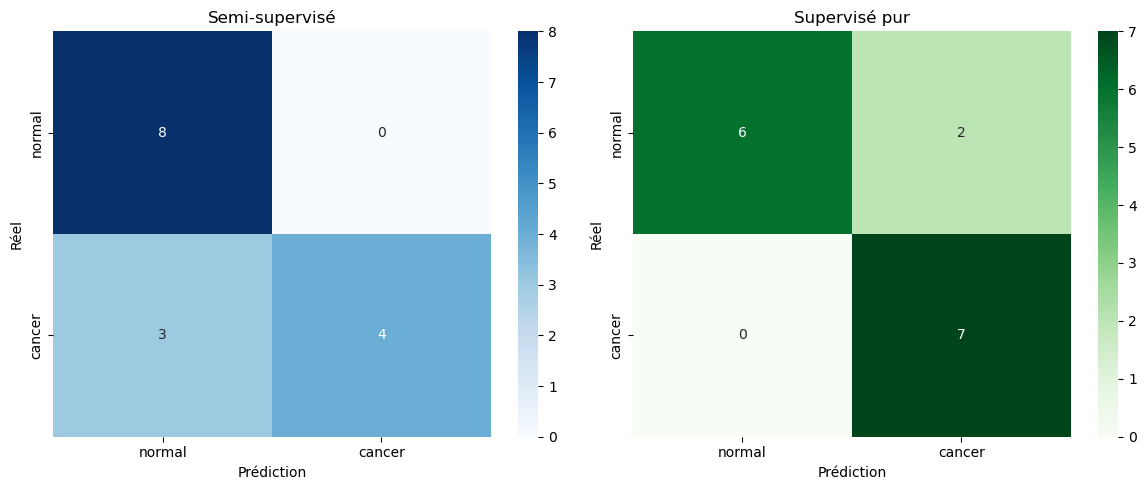

In [18]:
semi_model.load_state_dict(torch.load(semi_best_path, map_location=DEVICE))
sup_model.load_state_dict(torch.load(sup_best_path, map_location=DEVICE))

semi_results = evaluate_model(semi_model, test_loader, semi_criterion)
sup_results = evaluate_model(sup_model, test_loader, sup_criterion)

print("=== Résultats semi-supervisé ===")
print("Test accuracy:", semi_results['test_acc'])
print(classification_report(semi_results['y_true'], semi_results['y_pred'], target_names=['normal', 'cancer']))

print("\n=== Résultats supervisé pur ===")
print("Test accuracy:", sup_results['test_acc'])
print(classification_report(sup_results['y_true'], sup_results['y_pred'], target_names=['normal', 'cancer']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_semi = confusion_matrix(semi_results['y_true'], semi_results['y_pred'])
cm_sup = confusion_matrix(sup_results['y_true'], sup_results['y_pred'])

sns.heatmap(cm_semi, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'cancer'],
            yticklabels=['normal', 'cancer'],
            ax=axes[0])
axes[0].set_title('Semi-supervisé')
axes[0].set_xlabel('Prédiction')
axes[0].set_ylabel('Réel')

sns.heatmap(cm_sup, annot=True, fmt='d', cmap='Greens',
            xticklabels=['normal', 'cancer'],
            yticklabels=['normal', 'cancer'],
            ax=axes[1])
axes[1].set_title('Supervisé pur')
axes[1].set_xlabel('Prédiction')
axes[1].set_ylabel('Réel')

plt.tight_layout()
plt.show()

## 8. Sauvegarde finale

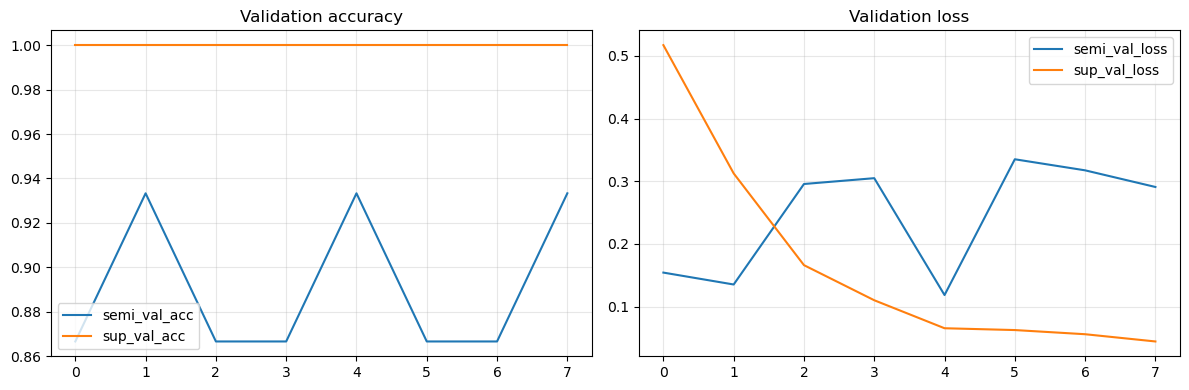

Résultats sauvegardés dans : ../results/semi_vs_supervised_comparison.json


In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(semi_history['val_acc'], label='semi_val_acc')
plt.plot(sup_history['val_acc'], label='sup_val_acc')
plt.title('Validation accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(semi_history['val_loss'], label='semi_val_loss')
plt.plot(sup_history['val_loss'], label='sup_val_loss')
plt.title('Validation loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

comparison_results = {
    'semi_supervised': {
        'test_acc': semi_results['test_acc'],
        'precision_cancer': semi_results['precision_cancer'],
        'recall_cancer': semi_results['recall_cancer'],
        'f1_cancer': semi_results['f1_cancer'],
        'precision_normal': semi_results['precision_normal'],
        'recall_normal': semi_results['recall_normal'],
        'f1_normal': semi_results['f1_normal'],
        'best_val_acc': float(semi_best_val_acc)
    },
    'supervised_only': {
        'test_acc': sup_results['test_acc'],
        'precision_cancer': sup_results['precision_cancer'],
        'recall_cancer': sup_results['recall_cancer'],
        'f1_cancer': sup_results['f1_cancer'],
        'precision_normal': sup_results['precision_normal'],
        'recall_normal': sup_results['recall_normal'],
        'f1_normal': sup_results['f1_normal'],
        'best_val_acc': float(sup_best_val_acc)
    },
    'train_sizes': {
        'semi_supervised_train_size': int(len(semi_train_idx)),
        'supervised_train_size': int(len(sup_train_idx)),
        'val_size': int(len(labeled_val_idx)),
        'test_size': int(len(labeled_test_idx))
    }
}

comparison_path = RESULTS_DIR / 'semi_vs_supervised_comparison.json'
with open(comparison_path, 'w', encoding='utf-8') as f:
    json.dump(comparison_results, f, indent=2, ensure_ascii=False)

print("Résultats sauvegardés dans :", comparison_path)